# High Performer Retention & 9-Box Analysis

## Objective
Identify high performers, analyze retention patterns, and build 9-box talent matrix.

## Key Questions
1. Who are our high performers?
2. How do we retain high vs. average vs. low performers?
3. What does our 9-box talent matrix look like?
4. Are high performers being promoted appropriately?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
print("Loading data...")
workforce = pd.read_csv('../data/current_workforce.csv')
nine_box = pd.read_csv('../data/nine_box.csv')
promotions = pd.read_csv('../data/promotions.csv')

print(f"Workforce: {len(workforce)} employees")
print(f"9-Box data: {len(nine_box)} employees")
print(f"Promotions: {len(promotions)} records")

Loading data...
Workforce: 500 employees
9-Box data: 500 employees
Promotions: 48 records


## 1. High Performer Identification

In [2]:
# Define performance tiers
workforce['performance_tier'] = pd.cut(workforce['latest_rating'], 
                                        bins=[0, 2, 3, 4, 5], 
                                        labels=['Low (1-2)', 'Average (3)', 'High (4)', 'Outstanding (5)'])

tier_counts = workforce['performance_tier'].value_counts()

print("\nPERFORMANCE TIER DISTRIBUTION")
print("="*70)
print(f"{'Tier':<25} {'Count':<15} {'Percentage':<15}")
print("="*70)
for tier in ['Outstanding (5)', 'High (4)', 'Average (3)', 'Low (1-2)']:
    count = tier_counts.get(tier, 0)
    pct = (count / len(workforce) * 100)
    print(f"{tier:<25} {count:<15} {pct:.1f}%")
print("="*70)

# High performer profile
high_performers = workforce[workforce['latest_rating'] >= 4]
print(f"\nHigh Performer Profile (n={len(high_performers)}):")
print(f"  Average Tenure: {high_performers['tenure_months'].mean()/12:.1f} years")
print(f"  Average Salary: ${high_performers['base_salary'].mean():,.0f}")
print(f"\nTop Departments for High Performers:")
dept_high_perf = high_performers['department'].value_counts().head(5)
for dept, count in dept_high_perf.items():
    pct = count / high_performers.shape[0] * 100
    print(f"  {dept}: {count} ({pct:.1f}%)")


PERFORMANCE TIER DISTRIBUTION
Tier                      Count           Percentage     
Outstanding (5)           36              7.2%
High (4)                  142             28.4%
Average (3)               226             45.2%
Low (1-2)                 96              19.2%

High Performer Profile (n=178):
  Average Tenure: 3.4 years
  Average Salary: $134,437

Top Departments for High Performers:
  Engineering: 46 (25.8%)
  Sales: 38 (21.3%)
  Marketing: 25 (14.0%)
  Product: 22 (12.4%)
  Customer Success: 18 (10.1%)


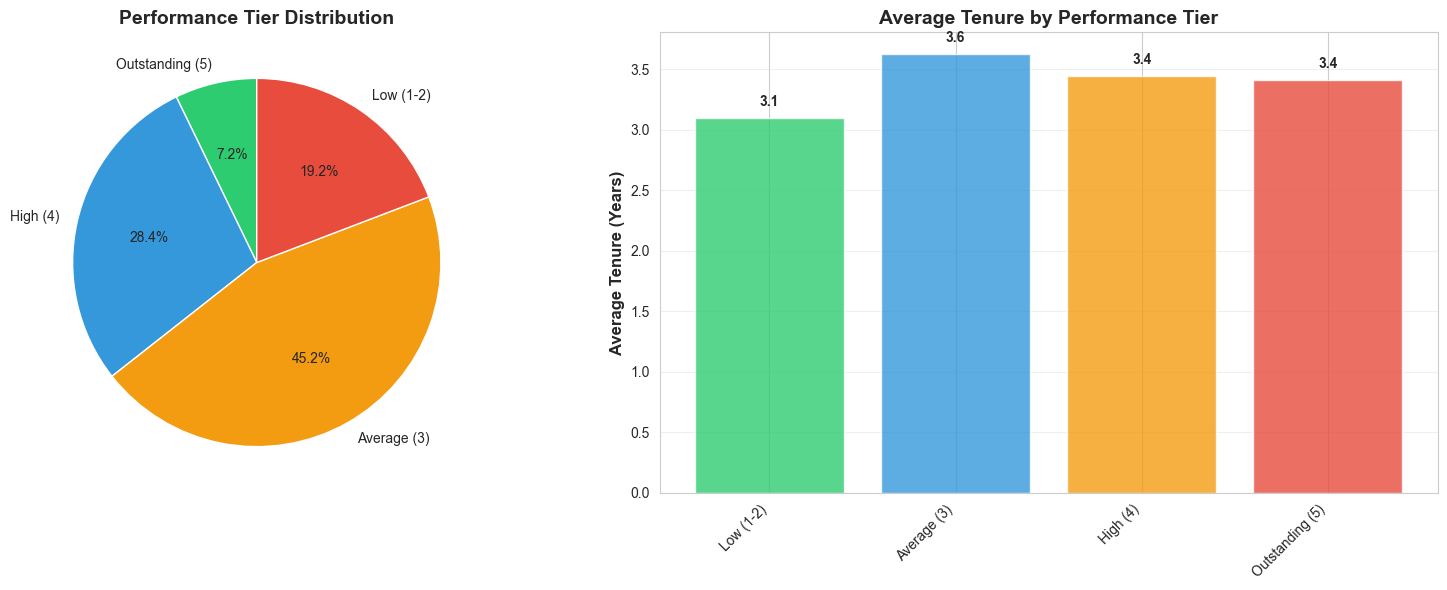

In [3]:
# Visualize performance tiers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
tier_order = ['Outstanding (5)', 'High (4)', 'Average (3)', 'Low (1-2)']
tier_data = [tier_counts.get(t, 0) for t in tier_order]

ax1.pie(tier_data, labels=tier_order, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Performance Tier Distribution', fontsize=14, fontweight='bold')

# Tenure by performance tier
tenure_by_tier = workforce.groupby('performance_tier')['tenure_months'].mean() / 12
ax2.bar(range(len(tenure_by_tier)), tenure_by_tier.values, color=colors[:len(tenure_by_tier)], alpha=0.8)
ax2.set_xticks(range(len(tenure_by_tier)))
ax2.set_xticklabels(tenure_by_tier.index, rotation=45, ha='right')
ax2.set_ylabel('Average Tenure (Years)', fontsize=12, fontweight='bold')
ax2.set_title('Average Tenure by Performance Tier', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, val in enumerate(tenure_by_tier.values):
    ax2.text(i, val + 0.1, f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. 9-Box Talent Matrix

In [4]:
# 9-box distribution
box_dist = nine_box['nine_box_segment'].value_counts()

print("\n9-BOX TALENT MATRIX DISTRIBUTION")
print("="*70)
print(f"{'Segment':<30} {'Count':<15} {'Percentage':<15}")
print("="*70)

segment_order = [
    'Star / Top Talent',
    'High Professional',
    'Subject Matter Expert',
    'High Potential / Enigma',
    'Core Contributor',
    'Solid Performer',
    'Inconsistent / Enigma',
    'Needs Development',
    'Low Performer'
]

for segment in segment_order:
    count = box_dist.get(segment, 0)
    pct = (count / len(nine_box) * 100)
    print(f"{segment:<30} {count:<15} {pct:.1f}%")

print("="*70)
print(f"\nHigh Potential Employees: {nine_box['high_potential_flag'].sum()} ({nine_box['high_potential_flag'].sum()/len(nine_box)*100:.1f}%)")

# Stars (high/high)
stars = nine_box[nine_box['nine_box_segment'] == 'Star / Top Talent']
print(f"Stars (High Performance + High Potential): {len(stars)} ({len(stars)/len(nine_box)*100:.1f}%)")


9-BOX TALENT MATRIX DISTRIBUTION
Segment                        Count           Percentage     
Star / Top Talent              128             25.6%
High Professional              50              10.0%
Subject Matter Expert          0               0.0%
High Potential / Enigma        29              5.8%
Core Contributor               144             28.8%
Solid Performer                53              10.6%
Inconsistent / Enigma          0               0.0%
Needs Development              34              6.8%
Low Performer                  62              12.4%

High Potential Employees: 157 (31.4%)
Stars (High Performance + High Potential): 128 (25.6%)


In [ ]:
# Visualize 9-box matrix
fig, ax = plt.subplots(figsize=(14, 10))

# Create pivot table for heatmap
pivot_data = nine_box.groupby(['performance_category', 'potential_category']).size().unstack(fill_value=0)
pivot_data = pivot_data.reindex(['Low', 'Medium', 'High'], axis=0)
pivot_data = pivot_data.reindex(['Low', 'Medium', 'High'], axis=1)

# Create custom colormap: white to green (avoiding red)
from matplotlib.colors import LinearSegmentedColormap
colors_cmap = ['#ffffff', '#d4edda', '#7bc96f', '#28a745']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_green', colors_cmap, N=n_bins)

# Create heatmap with larger font for annotations
sns.heatmap(pivot_data, annot=True, fmt='d', cmap=cmap, cbar_kws={'label': 'Employee Count'},
            linewidths=2, linecolor='black', ax=ax, annot_kws={'fontsize': 16, 'fontweight': 'bold'})

ax.set_xlabel('Potential →', fontsize=14, fontweight='bold')
ax.set_ylabel('Performance →', fontsize=14, fontweight='bold')
ax.set_title('9-Box Talent Matrix', fontsize=16, fontweight='bold', pad=20)

# Add quadrant labels outside the heatmap area with better positioning
# Top-right: Stars
ax.text(3.5, 0.5, 'STARS\n(High Perf + High Potential)\nRetain & Develop', 
        ha='left', va='center', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Top-left: Low Performers
ax.text(-0.5, 1.5, 'LOW PERFORMERS\n(Low Perf + Low Potential)\nPerformance Manage', 
        ha='right', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.7))

# Bottom-right: Subject Matter Experts
ax.text(3.5, 2.5, 'SUBJECT MATTER\nEXPERTS\n(High Perf + Low Potential)', 
        ha='left', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Top-middle-right: Enigmas
ax.text(3.5, 1.5, 'ENIGMAS\n(Low Perf + High Potential)\nCoach or Move', 
        ha='left', va='center', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

## 3. Promotion Analysis

In [6]:
# Merge promotions with workforce
promo_analysis = promotions.merge(workforce[['employee_id', 'department', 'latest_rating']], on='employee_id')

print("\nPROMOTION ANALYSIS")
print("="*70)
print(f"Total promotions (last 2 years): {len(promotions)}")
print(f"Average tenure at promotion: {promotions['tenure_at_promotion_months'].mean()/12:.1f} years")

# Promotion rate by performance rating
print("\nPromotion Rate by Performance Rating:")
for rating in [5, 4, 3, 2, 1]:
    total_at_rating = len(workforce[workforce['latest_rating'] == rating])
    promoted_at_rating = len(promo_analysis[promo_analysis['performance_rating_at_promotion'] == rating])
    if total_at_rating > 0:
        promo_rate = promoted_at_rating / total_at_rating * 100
        print(f"  Rating {rating}: {promoted_at_rating}/{total_at_rating} promoted ({promo_rate:.1f}%)")

# High performers promoted
high_perf_promoted = len(promo_analysis[promo_analysis['performance_rating_at_promotion'] >= 4])
high_perf_promo_pct = high_perf_promoted / len(promotions) * 100

print(f"\nPromotions from High Performers (4-5 rating): {high_perf_promoted}/{len(promotions)} ({high_perf_promo_pct:.1f}%)")
if high_perf_promo_pct < 70:
    print("⚠️ Target is >80% of promotions from top performers")
else:
    print("✓ Promotions aligned with performance")


PROMOTION ANALYSIS
Total promotions (last 2 years): 48
Average tenure at promotion: 3.1 years

Promotion Rate by Performance Rating:
  Rating 5: 10/36 promoted (27.8%)
  Rating 4: 27/142 promoted (19.0%)
  Rating 3: 10/226 promoted (4.4%)
  Rating 2: 1/84 promoted (1.2%)
  Rating 1: 0/12 promoted (0.0%)

Promotions from High Performers (4-5 rating): 37/48 (77.1%)
✓ Promotions aligned with performance


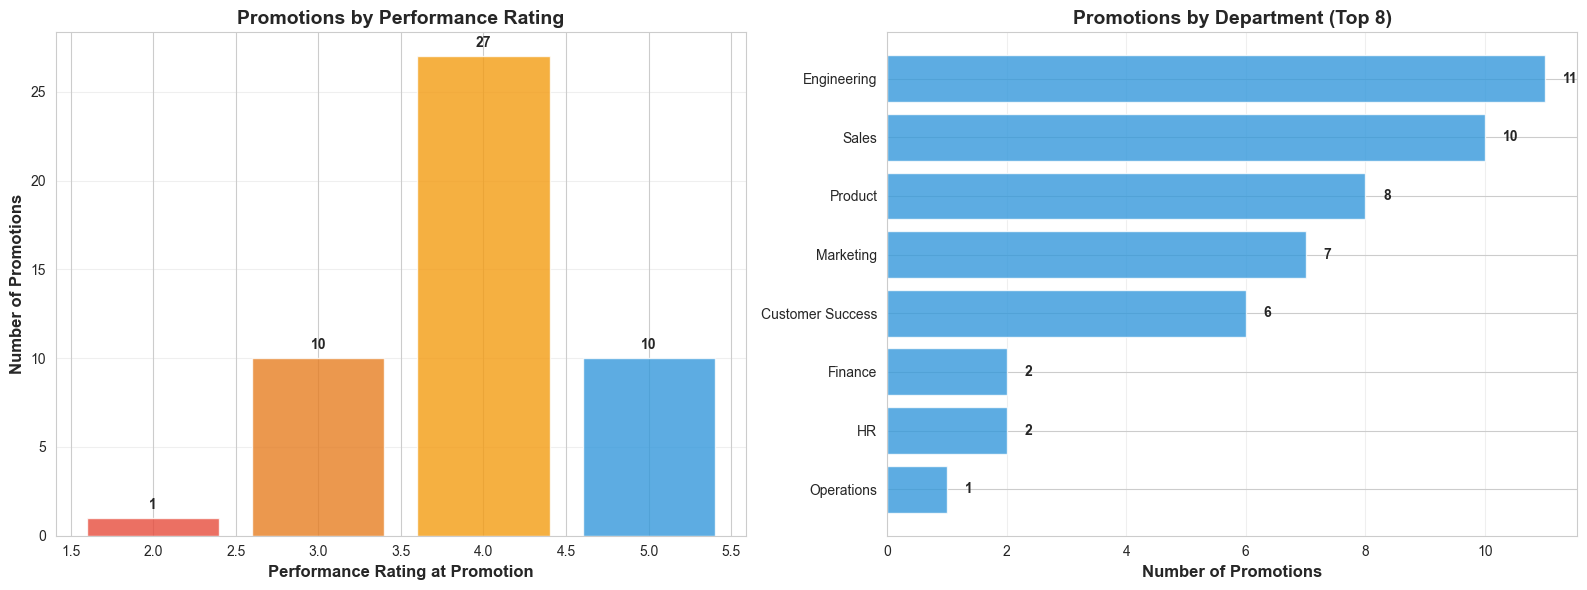

In [7]:
# Visualize promotions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Promotions by rating
promo_by_rating = promo_analysis['performance_rating_at_promotion'].value_counts().sort_index()
colors_rating = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71']
ax1.bar(promo_by_rating.index, promo_by_rating.values, color=colors_rating, alpha=0.8)
ax1.set_xlabel('Performance Rating at Promotion', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Promotions', fontsize=12, fontweight='bold')
ax1.set_title('Promotions by Performance Rating', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, val in zip(promo_by_rating.index, promo_by_rating.values):
    ax1.text(i, val + 0.5, str(val), ha='center', fontweight='bold')

# Promotions by department
promo_by_dept = promo_analysis['department'].value_counts().head(8)
ax2.barh(range(len(promo_by_dept)), promo_by_dept.values, color='#3498db', alpha=0.8)
ax2.set_yticks(range(len(promo_by_dept)))
ax2.set_yticklabels(promo_by_dept.index)
ax2.set_xlabel('Number of Promotions', fontsize=12, fontweight='bold')
ax2.set_title('Promotions by Department (Top 8)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, val in enumerate(promo_by_dept.values):
    ax2.text(val + 0.3, i, str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Performance-Compensation Alignment

In [8]:
# Salary by performance tier
salary_by_perf = workforce.groupby('performance_tier')['base_salary'].agg(['mean', 'median', 'count'])
salary_by_perf = salary_by_perf.round(0)

print("\nSALARY BY PERFORMANCE TIER")
print("="*80)
print(f"{'Tier':<25} {'Avg Salary':<20} {'Median Salary':<20} {'Count':<10}")
print("="*80)
for tier in ['Outstanding (5)', 'High (4)', 'Average (3)', 'Low (1-2)']:
    if tier in salary_by_perf.index:
        row = salary_by_perf.loc[tier]
        print(f"{tier:<25} ${row['mean']:>18,.0f} ${row['median']:>18,.0f} {int(row['count']):<10}")
print("="*80)

# Calculate correlation
correlation = workforce['latest_rating'].corr(workforce['base_salary'])
print(f"\nCorrelation (Performance × Salary): {correlation:.3f}")
print("\nInterpretation:")
print("  r > 0.5: Strong pay-for-performance alignment (TARGET)")
print("  r 0.3-0.5: Moderate alignment")
print("  r < 0.3: Weak alignment - compensation not differentiated by performance")

if correlation < 0.3:
    print("\n⚠️ Weak performance-pay correlation. Consider:")
    print("   → Review compensation strategy")
    print("   → Ensure merit increases tied to performance")
elif correlation < 0.5:
    print("\n⚠️ Moderate correlation. Room for improvement in pay differentiation.")
else:
    print("\n✓ Strong pay-for-performance alignment.")


SALARY BY PERFORMANCE TIER
Tier                      Avg Salary           Median Salary        Count     
Outstanding (5)           $           135,730 $           139,017 36        
High (4)                  $           134,110 $           121,140 142       
Average (3)               $           127,293 $           121,599 226       
Low (1-2)                 $           137,332 $           132,681 96        

Correlation (Performance × Salary): 0.002

Interpretation:
  r > 0.5: Strong pay-for-performance alignment (TARGET)
  r 0.3-0.5: Moderate alignment
  r < 0.3: Weak alignment - compensation not differentiated by performance

⚠️ Weak performance-pay correlation. Consider:
   → Review compensation strategy
   → Ensure merit increases tied to performance


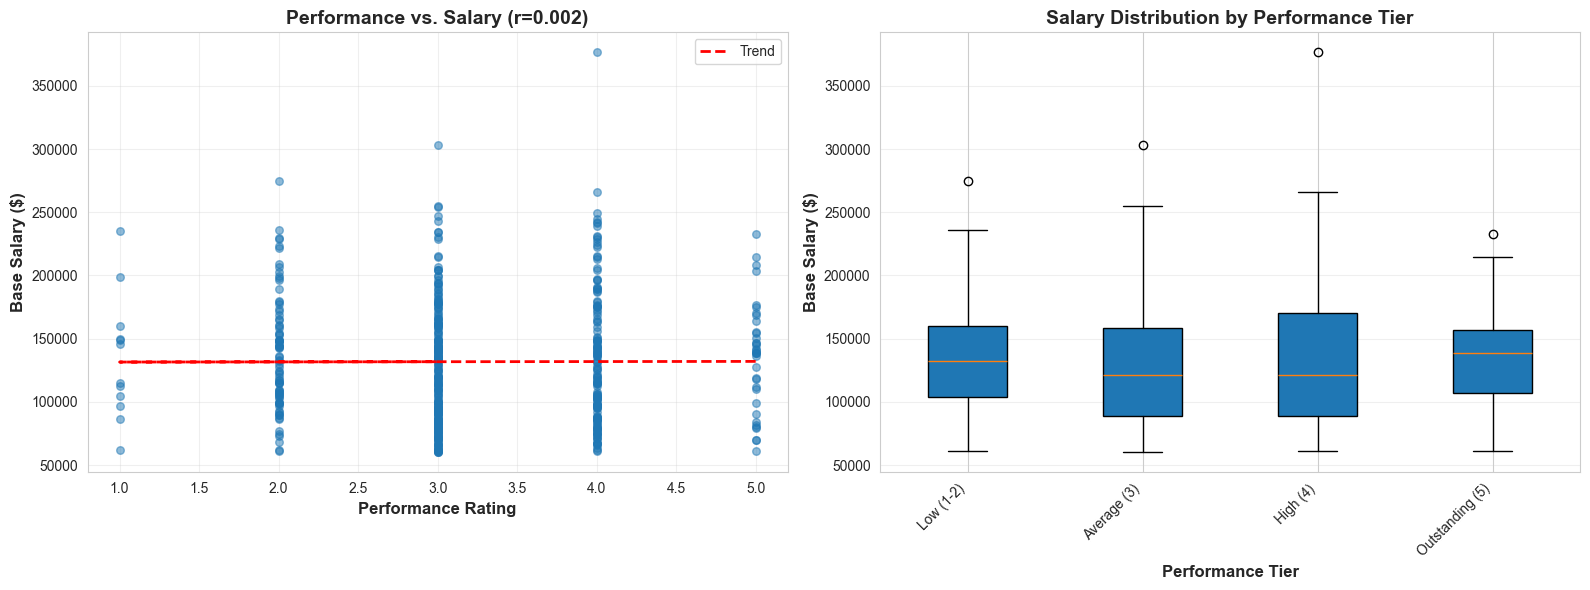

In [9]:
# Visualize performance-salary relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
ax1.scatter(workforce['latest_rating'], workforce['base_salary'], alpha=0.5, s=30)
ax1.set_xlabel('Performance Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Base Salary ($)', fontsize=12, fontweight='bold')
ax1.set_title(f'Performance vs. Salary (r={correlation:.3f})', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# Add trend line
z = np.polyfit(workforce['latest_rating'], workforce['base_salary'], 1)
p = np.poly1d(z)
ax1.plot(workforce['latest_rating'], p(workforce['latest_rating']), "r--", linewidth=2, label='Trend')
ax1.legend()

# Box plot
tier_order = ['Low (1-2)', 'Average (3)', 'High (4)', 'Outstanding (5)']
data_for_box = [workforce[workforce['performance_tier'] == t]['base_salary'] for t in tier_order]
ax2.boxplot(data_for_box, labels=tier_order, patch_artist=True)
ax2.set_xlabel('Performance Tier', fontsize=12, fontweight='bold')
ax2.set_ylabel('Base Salary ($)', fontsize=12, fontweight='bold')
ax2.set_title('Salary Distribution by Performance Tier', fontsize=14, fontweight='bold')
ax2.set_xticklabels(tier_order, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Key Recommendations

In [10]:
print("\n" + "="*80)
print("KEY RECOMMENDATIONS")
print("="*80)

# Stars and high potentials
stars = nine_box[nine_box['nine_box_segment'] == 'Star / Top Talent']
high_potential_all = nine_box[nine_box['high_potential_flag'] == True]

print("\n1. RETAIN TOP TALENT (STARS)")
print(f"   → {len(stars)} employees in Star segment (High Performance + High Potential)")
print("   → Actions:")
print("     - Fast-track development programs")
print("     - Retention bonuses and equity refresh")
print("     - Stretch assignments and visibility to executives")
print("     - Quarterly check-ins with senior leadership")

print("\n2. DEVELOP HIGH POTENTIALS")
print(f"   → {len(high_potential_all)} total high potential employees across all segments")
enigmas = nine_box[nine_box['nine_box_segment'] == 'High Potential / Enigma']
if len(enigmas) > 0:
    print(f"   → {len(enigmas)} high-potential employees with inconsistent performance (Enigmas)")
    print("     Action: Intensive coaching, role clarification, or role change")

print("\n3. PROMOTION FAIRNESS")
high_perf_promo_pct = len(promo_analysis[promo_analysis['performance_rating_at_promotion'] >= 4]) / len(promotions) * 100
print(f"   → {high_perf_promo_pct:.1f}% of promotions from high performers (Target: >80%)")
if high_perf_promo_pct < 80:
    print("   ⚠️ Ensure promotions are merit-based, not tenure-based")
else:
    print("   ✓ Promotions aligned with performance")

print("\n4. COMPENSATION ALIGNMENT")
high_perf_salary_gap = (salary_by_perf.loc['Outstanding (5)', 'mean'] - salary_by_perf.loc['Average (3)', 'mean']) / salary_by_perf.loc['Average (3)', 'mean'] * 100
print(f"   → Outstanding performers earn {high_perf_salary_gap:.1f}% more than average")
if high_perf_salary_gap < 15:
    print("   ⚠️ Insufficient pay differentiation. Target: 15-25% premium for top performers")
else:
    print("   ✓ Appropriate pay differentiation")

print("\n5. LOW PERFORMER ACTION")
low_performers = nine_box[nine_box['nine_box_segment'] == 'Low Performer']
needs_dev = nine_box[nine_box['nine_box_segment'] == 'Needs Development']
print(f"   → {len(low_performers)} low performers (Low Performance + Low Potential)")
print(f"   → {len(needs_dev)} employees needing development")
print("   → Action: Performance improvement plans, coaching, or managed exits")

print("\n" + "="*80)
print("Next Analysis: See '03_productivity_analysis.ipynb' for deep dive")
print("on productivity metrics and performance trends over time")
print("="*80)


KEY RECOMMENDATIONS

1. RETAIN TOP TALENT (STARS)
   → 128 employees in Star segment (High Performance + High Potential)
   → Actions:
     - Fast-track development programs
     - Retention bonuses and equity refresh
     - Stretch assignments and visibility to executives
     - Quarterly check-ins with senior leadership

2. DEVELOP HIGH POTENTIALS
   → 157 total high potential employees across all segments
   → 29 high-potential employees with inconsistent performance (Enigmas)
     Action: Intensive coaching, role clarification, or role change

3. PROMOTION FAIRNESS
   → 77.1% of promotions from high performers (Target: >80%)
   ⚠️ Ensure promotions are merit-based, not tenure-based

4. COMPENSATION ALIGNMENT
   → Outstanding performers earn 6.6% more than average
   ⚠️ Insufficient pay differentiation. Target: 15-25% premium for top performers

5. LOW PERFORMER ACTION
   → 62 low performers (Low Performance + Low Potential)
   → 34 employees needing development
   → Action: Perfor